# Figure 1: Reproduce Stata Figure 1 with pandas and matplotlib
This notebook loads `data/cleaned_data.csv`, prepares the same subset used by the Stata Figure 1 code, and plots the cumulative distribution functions of `prob_true` for Pro-Party and Anti-Party politicized news.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [7]:
data_path = 'data/cleaned_data.csv'

df = pd.read_csv(data_path)

df.head()

,id_in_session,code,index_in_pages,current_page_name,time_started,payoff,consent,treatment,age_temp,gender,...,mean_prob_rep_temp,mean_prob_rep,mean_prob_dem_temp,mean_prob_dem,mean_prob_net,mean_prob_net_mean,mean_prob_net_sd,mean_prob_net_z,out_of_range_q,out_of_range
0,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
1,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
2,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,0.7,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
3,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,0.516667,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
4,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0


In [9]:
# Filter to the same sample used by the Stata code for Figure 1
mask = (
    ((df['good_news'] + df['bad_news']) > 0)
    & ((df['pro_party'] + df['anti_party']) > 0)
)
sub = df.loc[mask].copy()

# Group labels used for plotting
sub['news_type'] = np.where(sub['good_news'] == 1, 'Pro-Party News', 'Anti-Party News')

sub['prob_true'] = pd.to_numeric(sub['prob_true'], errors='coerce')
sub = sub.dropna(subset=['prob_true'])

sub['news_type'].value_counts()

news_type
Anti-Party News    3961
Pro-Party News     3941
Name: count, dtype: int64

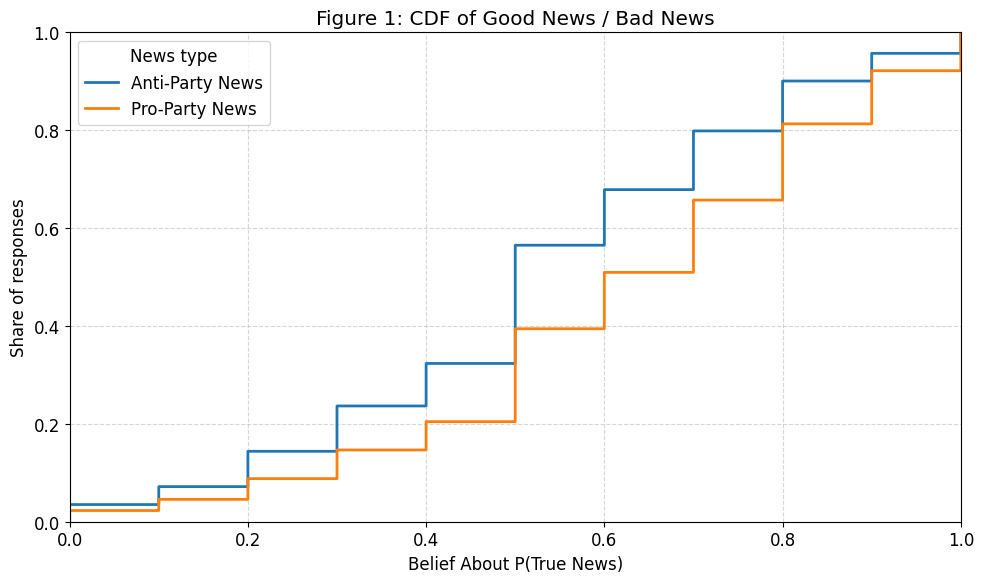

In [10]:
def ecdf(series):
    x = np.sort(series)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(10, 6))
for label, group in sub.groupby('news_type'):
    x, y = ecdf(group['prob_true'])
    plt.step(x, y, where='post', label=label, linewidth=2)

plt.xlabel('Belief About P(True News)')
plt.ylabel('Share of responses')
plt.title('Figure 1: CDF of Good News / Bad News')
plt.legend(title='News type')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()